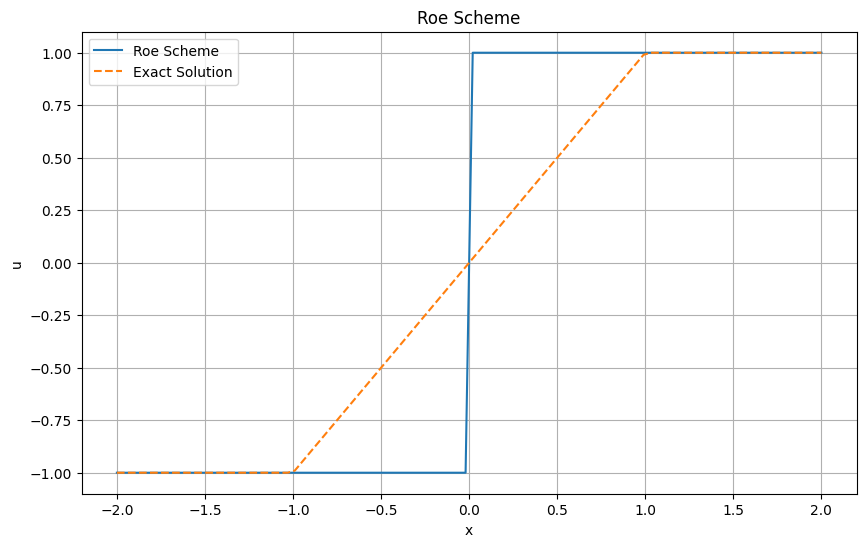

In [4]:
import numpy as np
import matplotlib.pyplot as plt


L = 2.0              
N = 100              
dx = L / N
x = np.linspace(-L, L, N)

T = 1.0             
CFL = 0.5
dt = CFL * dx      
Nt = int(T / dt)

def roe_flux(u, v):
    c = (0.5 * (u + v))
    if c>=0:
        return u**2 /2
    else:
        return v**2 /2


u = np.where(x <= 0, -1.0, 1.0)
u_new = np.copy(u)

for n in range(Nt):
    for i in range(1, N-1):
        u_new[i] = u[i] - dt/dx * (roe_flux(u[i], u[i+1]) - roe_flux(u[i-1], u[i]))
    u = np.copy(u_new)

u_exact = np.zeros_like(u)

for i in range(N):

    if x[i] < -1.0:
        u_exact[i] = -1.0
    elif x[i] > 1.0:
        u_exact[i] = 1.0
    else:
        u_exact[i] = x[i] / T

plt.figure(figsize=(10, 6))
plt.plot(x, u, label='Roe Scheme')
plt.plot(x, u_exact, label='Exact Solution', linestyle='dashed')
plt.xlabel('x')
plt.ylabel('u')
plt.title('Roe Scheme')
plt.legend()
plt.grid()
plt.show()